# SWAP Count vs Noisy Hardware Fidelity

Demonstrates that circuits generated with fewer SWAP gates achieve higher
fidelity when executed on a realistic noisy hardware simulator.

**Experimental setup:**
- Model: `unitary_swap_finetuned` (fine-tuned from baseline, 75 epochs, lr 3e-5)
- For each target unitary, generate circuits at `swap_count ∈ {0, 1, 2, 3}`
- Keep only circuits that **exactly** implement the target unitary (noiseless infidelity < 1e-8)
- Simulate each exact circuit under a depolarizing noise model calibrated to
  typical IBM Quantum gate error rates
- Compare noisy state fidelity across SWAP counts

**Noise model:**  depolarising errors — single-qubit gates p₁ = 0.1 %, two-qubit gates p₂ = 1 %,
SWAP p_swap = 3 %, CCX p_ccx = 6 %.  These match typical IBM Falcon / Heron device specs.


In [1]:
import random
import sys
from pathlib import Path

import hydra
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra.core.global_hydra import GlobalHydra
from IPython.display import display
from qiskit.quantum_info import DensityMatrix, Statevector, state_fidelity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from tqdm.auto import tqdm

sys.path.append("/home/a-ldungl/projects/qcircuit-generation")

from notebooks.shared.bootstrap import setup_notebook_paths
PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import (
    make_artifact_dir, save_dataframe, save_figure, save_json,
)
from my_genQC.inference.eval_metrics import UnitaryInfidelityNorm
from my_genQC.inference.sampling import decode_tensors_to_backend, generate_compilation_tensors
from my_genQC.pipeline.diffusion_pipeline import DiffusionPipeline
from my_genQC.platform.simulation import CircuitBackendType, Simulator
from my_genQC.platform.tokenizer.circuits_tokenizer import CircuitTokenizer
from my_genQC.utils.misc_utils import infer_torch_device
from quantum_diffusion.data.dataset import DatasetLoader

# ── Thesis-grade plot style (AGENTS.md) ───────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":          150,
    "figure.facecolor":    "white",
    "axes.facecolor":      "white",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.titlesize":      13,
    "axes.titleweight":    "bold",
    "axes.titlepad":       10,
    "axes.labelsize":      11,
    "axes.labelpad":       6,
    "axes.grid":           True,
    "grid.linestyle":      "--",
    "grid.linewidth":      0.6,
    "grid.alpha":          0.5,
    "grid.color":          "#AAAAAA",
    "axes.axisbelow":      True,
    "xtick.labelsize":     10,
    "ytick.labelsize":     10,
    "legend.fontsize":     10,
    "legend.framealpha":   0.92,
    "legend.edgecolor":    "#CCCCCC",
    "lines.linewidth":     2.0,
    "lines.markersize":    6,
    "font.family":         "sans-serif",
})

# Colour palette (AGENTS.md): assign by semantic role
C_SWAP0  = "#2176AE"   # primary   – no SWAPs (best)
C_SWAP1  = "#3BAA6E"   # tertiary  – 1 SWAP
C_SWAP2  = "#E05C2A"   # secondary – 2 SWAPs
C_SWAP3  = "#8B5CF6"   # quaternary – 3 SWAPs
SWAP_COLORS = {0: C_SWAP0, 1: C_SWAP1, 2: C_SWAP2, 3: C_SWAP3}


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────

EVAL_DATASET_PATH   = "./artifacts/datasets/unitary-baseline-reproduction/eval/qiskit"
FINETUNED_MODEL_DIR = "./artifacts/models/unitary-swap-finetuned/unitary_swap_finetuned"

SWAP_COUNTS        = [0, 1, 2, 3]
NUM_EVAL_UNITARIES = 64     # subset for speed; 64 gives robust statistics
SAMPLES_PER_UNITARY = 64    # samples per (unitary, swap_count) pair
GUIDANCE_SCALE     = 7.5
SAMPLE_STEPS       = 20
MAX_GATES          = 12
AUTO_BATCH_SIZE    = 128
EXACT_DISTANCE_TOL = 1e-8
SEED               = 42

# Noise model parameters (typical IBM Quantum gate error rates)
P1       = 0.001   # single-qubit gate depolarising error
P2       = 0.01    # two-qubit gate (CX) depolarising error
P_SWAP   = 0.03    # SWAP = 3 × CX
P_CCX    = 0.06    # Toffoli ≈ 6 × CX

ARTIFACT_SUBDIR = "unitary-swap-noise"
RUN_NAME        = "noise_simulation"

device = str(infer_torch_device())
print(f"Device: {device}")

ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, ARTIFACT_SUBDIR, RUN_NAME)
print(f"Artifacts: {ARTIFACT_DIR}")


[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
Device: cuda
Artifacts: /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-noise/noise_simulation


In [3]:
# ── Build depolarising noise model ────────────────────────────────────────────

noise_model = NoiseModel()

# Single-qubit gates
noise_model.add_all_qubit_quantum_error(depolarizing_error(P1, 1), ["h", "x", "z", "s", "t", "sdg", "tdg"])

# Two-qubit gates
noise_model.add_all_qubit_quantum_error(depolarizing_error(P2,    2), ["cx"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(P_SWAP, 2), ["swap"])

# Three-qubit gate (Toffoli)
noise_model.add_all_qubit_quantum_error(depolarizing_error(P_CCX, 3), ["ccx"])

noisy_sim = AerSimulator(noise_model=noise_model, method="density_matrix")
print("Noise model basis gates:", noise_model.basis_gates)
print(f"  p₁ (1q gates) = {P1:.3f}")
print(f"  p₂ (CX)       = {P2:.3f}")
print(f"  p_swap        = {P_SWAP:.3f}")
print(f"  p_ccx         = {P_CCX:.3f}")


Noise model basis gates: ['ccx', 'cx', 'h', 'id', 'rz', 's', 'sdg', 'swap', 'sx', 't', 'tdg', 'x', 'z']
  p₁ (1q gates) = 0.001
  p₂ (CX)       = 0.010
  p_swap        = 0.030
  p_ccx         = 0.060


In [4]:
# ── Load model and dataset ────────────────────────────────────────────────────

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# Dataset
GlobalHydra.instance().clear()
with hydra.initialize(version_base=None, config_path="../../../conf"):
    cfg = hydra.compose(config_name="config.yaml", overrides=["evaluation=paper_srv"])
eval_cfg = cfg["evaluation"]
eval_cfg.dataset    = str(Path(EVAL_DATASET_PATH).expanduser().resolve())
eval_cfg.model_dir  = str(Path(FINETUNED_MODEL_DIR).expanduser().resolve())
eval_cfg.save_output = False
eval_cfg.wandb.enable = False

loader = DatasetLoader(eval_cfg, device=device)
eval_dataset = loader.load_dataset(eval_cfg.dataset, load_embedder=False)
gate_pool = eval_dataset.gate_pool
print(f"Eval dataset: {len(eval_dataset.y):,} circuits | gate_pool: {gate_pool}")

vocabulary = {gate: idx for idx, gate in enumerate(gate_pool)}
tokenizer  = CircuitTokenizer(vocabulary)
simulator  = Simulator(CircuitBackendType.QISKIT)

# Finetuned pipeline
print("\nLoading finetuned pipeline...")
finetuned_pipeline = DiffusionPipeline.from_config_file(
    config_path=str(Path(FINETUNED_MODEL_DIR).expanduser().resolve()) + "/",
    device=device,
)
finetuned_pipeline.guidance_sample_mode = "rescaled"
finetuned_pipeline.scheduler.set_timesteps(SAMPLE_STEPS)
print("Done.")

# Eval indices (same selection as swap_constrained_evaluation.ipynb)
rng = random.Random(SEED)
eval_indices = rng.sample(range(len(eval_dataset.y)), k=NUM_EVAL_UNITARIES)
print(f"\nSelected {len(eval_indices)} target unitaries")


2026-05-25 17:11:09 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_x.safetensors` onto device: cuda.


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_U.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_z.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-25 17:11:09 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit


Eval dataset: 2,800 circuits | gate_pool: ['h', 'cx', 'z', 'x', 'ccx', 'swap']
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...

Loading finetuned pipeline...


[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/unitary-swap-finetuned/unitary_swap_finetuned/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True


[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/unitary-swap-finetuned/unitary_swap_finetuned/embedder.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True
Done.

Selected 64 target unitaries


In [5]:
# ── Helper functions ──────────────────────────────────────────────────────────

def make_prompt(swap_count):
    base = f"Compile using: {[str(g) for g in gate_pool]}"
    return f"{base}; swap_count={swap_count}" if swap_count is not None else base


def get_ideal_sv(qc):
    """Statevector for |000...0⟩ evolved through qc (noiseless)."""
    return Statevector(qc)


def noisy_state_fidelity(qc):
    """
    Density-matrix simulation under depolarising noise model.
    Returns F(ideal, ρ_noisy) where input is |000...0⟩.
    """
    ideal_sv = get_ideal_sv(qc)
    qc_sim = qc.copy()
    qc_sim.save_density_matrix()
    result = noisy_sim.run(qc_sim, shots=1).result()
    noisy_dm = result.data(0)["density_matrix"]
    return float(state_fidelity(DensityMatrix(ideal_sv), noisy_dm))


def get_reference_unitary(idx):
    """Recompute exact target unitary at float64 from stored reference circuit."""
    try:
        ref_instructions = tokenizer.decode(eval_dataset.x[idx])
        ref_qc = simulator.backend.genqc_to_backend(ref_instructions, place_barriers=False)
        return simulator.backend.get_unitary(ref_qc)
    except Exception:
        target_u_split = eval_dataset.U[idx].cpu()
        return target_u_split[0].numpy() + 1j * target_u_split[1].numpy()


def count_gates(qc):
    names = [inst.operation.name for inst in qc.data]
    return {
        "total_gates": len(names),
        "n_swap": names.count("swap"),
        "n_cx":   names.count("cx"),
        "n_ccx":  names.count("ccx"),
        "n_1q":   sum(1 for n in names if n in {"h","x","z","s","t","sdg","tdg","rx","ry","rz","u","sx"}),
    }


In [6]:
# ── Generate circuits and run noisy simulation ────────────────────────────────
# For each (unitary, swap_count) pair: generate SAMPLES_PER_UNITARY circuits,
# keep only those that exactly implement the target, simulate each under noise.

set_seed(SEED)
rows = []

for idx in tqdm(eval_indices, desc="Unitaries"):
    target_u_split = eval_dataset.U[idx].cpu()
    target_u = get_reference_unitary(idx)

    for swap_count in SWAP_COUNTS:
        prompt = make_prompt(swap_count)
        tensors_out = generate_compilation_tensors(
            pipeline=finetuned_pipeline,
            prompt=[prompt],
            U=target_u_split.float().unsqueeze(0).to(device),
            samples=SAMPLES_PER_UNITARY,
            system_size=eval_dataset.x.shape[1],
            num_of_qubits=getattr(eval_dataset.params_config, "num_of_qubits", eval_dataset.x.shape[1]),
            max_gates=MAX_GATES,
            g=GUIDANCE_SCALE,
            auto_batch_size=AUTO_BATCH_SIZE,
            enable_params=False,
            no_bar=True,
        )

        decoded, _ = decode_tensors_to_backend(
            simulator=simulator,
            tokenizer=tokenizer,
            tensors=tensors_out,
            params=None,
            silent=True,
            n_jobs=1,
            filter_errs=False,
        )

        for qc in decoded:
            if qc is None:
                continue
            gen_u = simulator.backend.get_unitary(qc)
            infidelity = float(UnitaryInfidelityNorm.distance(
                torch.as_tensor(gen_u).to(torch.complex128),
                torch.as_tensor(target_u).to(torch.complex128),
            ).item())
            exact = infidelity <= EXACT_DISTANCE_TOL
            actual_swap = sum(1 for inst in qc.data if inst.operation.name == "swap")

            row = {
                "dataset_idx":   idx,
                "swap_count_req": swap_count,
                "actual_swap":   actual_swap,
                "exact":         exact,
                "infidelity":    infidelity,
            }
            row.update(count_gates(qc))

            if exact:
                try:
                    row["noisy_fidelity"] = noisy_state_fidelity(qc)
                except Exception as e:
                    row["noisy_fidelity"] = float("nan")
            else:
                row["noisy_fidelity"] = float("nan")

            rows.append(row)

df_all = pd.DataFrame(rows)
df_exact = df_all[df_all["exact"]].copy()

print(f"\nTotal circuits evaluated: {len(df_all):,}")
print(f"Exact circuits: {len(df_exact):,}")
print(f"\nExact circuits per swap_count_req:")
print(df_exact.groupby("swap_count_req").size())


Unitaries:   0%|          | 0/64 [00:00<?, ?it/s]


Total circuits evaluated: 16,281
Exact circuits: 9,016

Exact circuits per swap_count_req:
swap_count_req
0    2163
1    2267
2    2598
3    1988
dtype: int64


In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────

summary_rows = []
for sc in SWAP_COUNTS:
    exact_u = df_exact[df_exact["swap_count_req"] == sc]
    # exact_found_rate: fraction of unitaries for which at least 1 exact sample found
    found_any = df_all[df_all["swap_count_req"] == sc].groupby("dataset_idx")["exact"].any()
    summary_rows.append({
        "swap_count_req":      sc,
        "exact_found_rate":    float(found_any.mean()),
        "n_exact_circuits":    len(exact_u),
        "mean_total_gates":    float(exact_u["total_gates"].mean()),
        "mean_actual_swap":    float(exact_u["actual_swap"].mean()),
        "mean_cx":             float(exact_u["n_cx"].mean()),
        "mean_noisy_fidelity": float(exact_u["noisy_fidelity"].mean()),
        "std_noisy_fidelity":  float(exact_u["noisy_fidelity"].std()),
        "median_noisy_fidelity": float(exact_u["noisy_fidelity"].median()),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))
save_dataframe(summary_df, ARTIFACT_DIR / "noise_summary.csv", index=False)


,swap_count_req,exact_found_rate,n_exact_circuits,mean_total_gates,mean_actual_swap,mean_cx,mean_noisy_fidelity,std_noisy_fidelity,median_noisy_fidelity
0,0,0.9844,2163,4.2797,0.0231,1.4753,0.9516,0.0366,0.9470
1,1,0.9219,2267,4.6277,1.2258,0.9012,0.9355,0.0378,0.9538
2,2,0.9062,2598,5.3911,2.1875,0.5858,0.9191,0.0348,0.9329
3,3,0.9062,1988,6.1539,3.2953,0.5131,0.8983,0.0344,0.9122


PosixPath('/home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-noise/noise_simulation/noise_summary.csv')

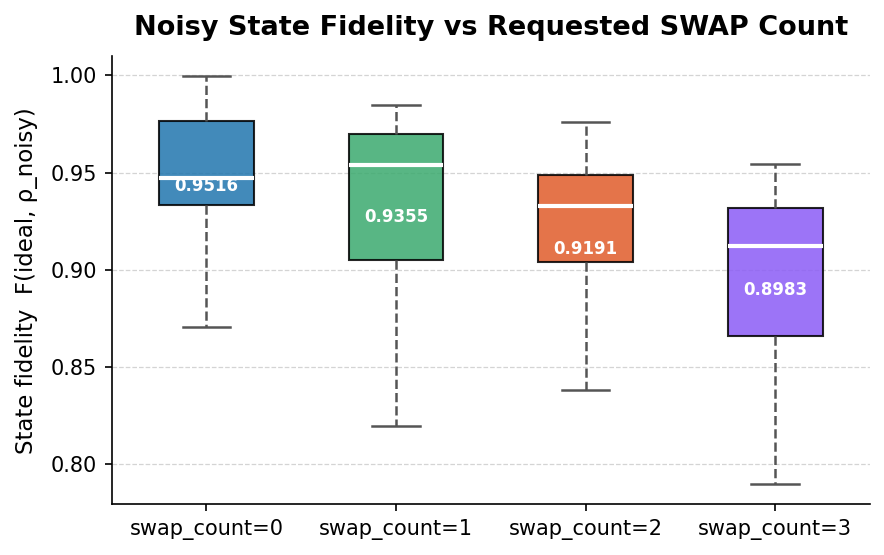

In [8]:
# ── Figure 1: Noisy state fidelity distribution per requested SWAP count ──────

fig, ax = plt.subplots(figsize=(6, 3.8))

positions = list(range(len(SWAP_COUNTS)))
data_per_count = [
    df_exact[df_exact["swap_count_req"] == sc]["noisy_fidelity"].dropna().values
    for sc in SWAP_COUNTS
]

bp = ax.boxplot(
    data_per_count,
    positions=positions,
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, sc in zip(bp["boxes"], SWAP_COUNTS):
    patch.set_facecolor(SWAP_COLORS[sc])
    patch.set_alpha(0.85)
for whisker in bp["whiskers"]:
    whisker.set(color="#555555", linewidth=1.2, linestyle="--")
for cap in bp["caps"]:
    cap.set(color="#555555", linewidth=1.2)

ax.set_xticks(positions)
ax.set_xticklabels([f"swap_count={sc}" for sc in SWAP_COUNTS])
ax.set_ylabel("State fidelity  F(ideal, ρ_noisy)")
ax.set_title("Noisy State Fidelity vs Requested SWAP Count")
ax.set_ylim(None, 1.01)
ax.yaxis.grid(True)
ax.xaxis.grid(False)

# Annotate with mean values
for pos, (sc, row) in enumerate(zip(SWAP_COUNTS, summary_rows)):
    ax.text(pos, row["mean_noisy_fidelity"] - 0.004,
            f'{row["mean_noisy_fidelity"]:.4f}',
            ha="center", va="top", fontsize=8, color="white", fontweight="bold")

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "noisy_fidelity_by_swap_count.png")
plt.show()


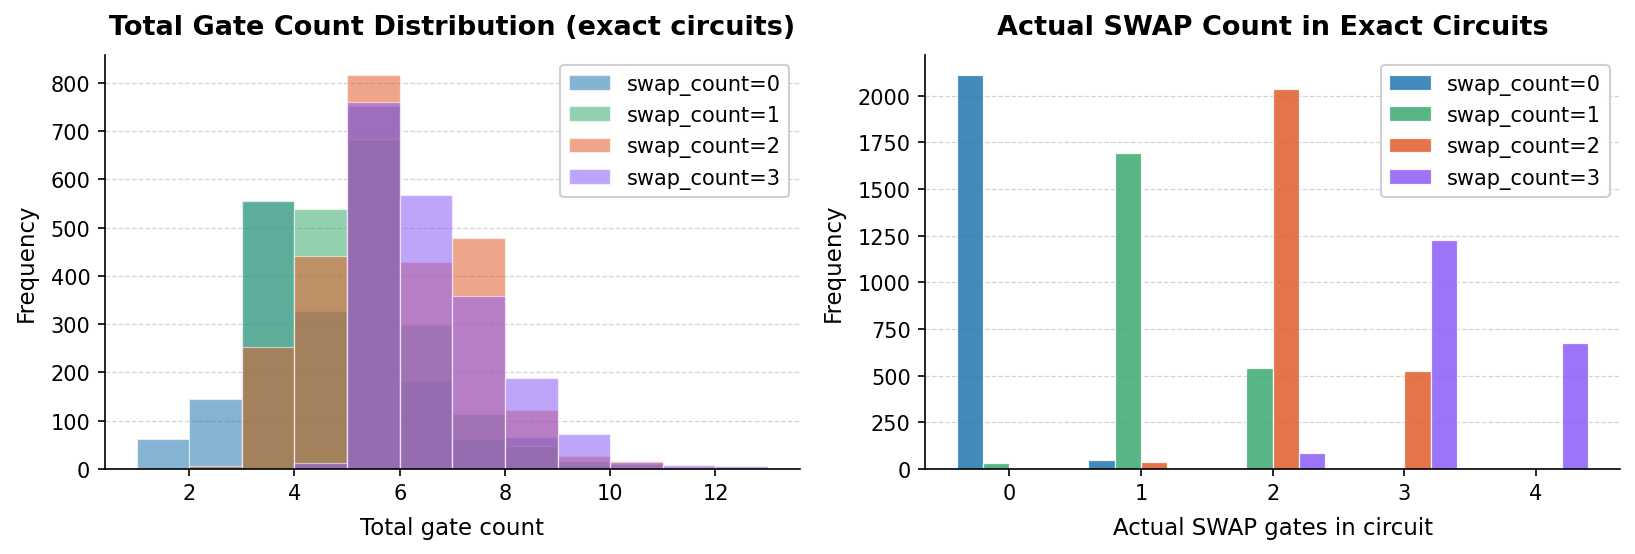

In [9]:
# ── Figure 2: Gate count and SWAP count distributions per requested count ──────

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: total gate count distribution
for sc in SWAP_COUNTS:
    vals = df_exact[df_exact["swap_count_req"] == sc]["total_gates"].dropna()
    axes[0].hist(vals, bins=range(1, MAX_GATES + 2), alpha=0.55,
                 label=f"swap_count={sc}", color=SWAP_COLORS[sc],
                 edgecolor="white", linewidth=0.6)
axes[0].set_xlabel("Total gate count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Total Gate Count Distribution (exact circuits)")
axes[0].legend()
axes[0].yaxis.grid(True)
axes[0].xaxis.grid(False)

# Right: actual SWAP count distribution
for sc in SWAP_COUNTS:
    vals = df_exact[df_exact["swap_count_req"] == sc]["actual_swap"].dropna()
    counts = vals.value_counts().sort_index()
    axes[1].bar(counts.index + sc * 0.2 - 0.3, counts.values, width=0.2,
                label=f"swap_count={sc}", color=SWAP_COLORS[sc], alpha=0.85,
                edgecolor="white", linewidth=0.6)
axes[1].set_xlabel("Actual SWAP gates in circuit")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Actual SWAP Count in Exact Circuits")
axes[1].legend()
axes[1].yaxis.grid(True)
axes[1].xaxis.grid(False)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "gate_count_distributions.png")
plt.show()


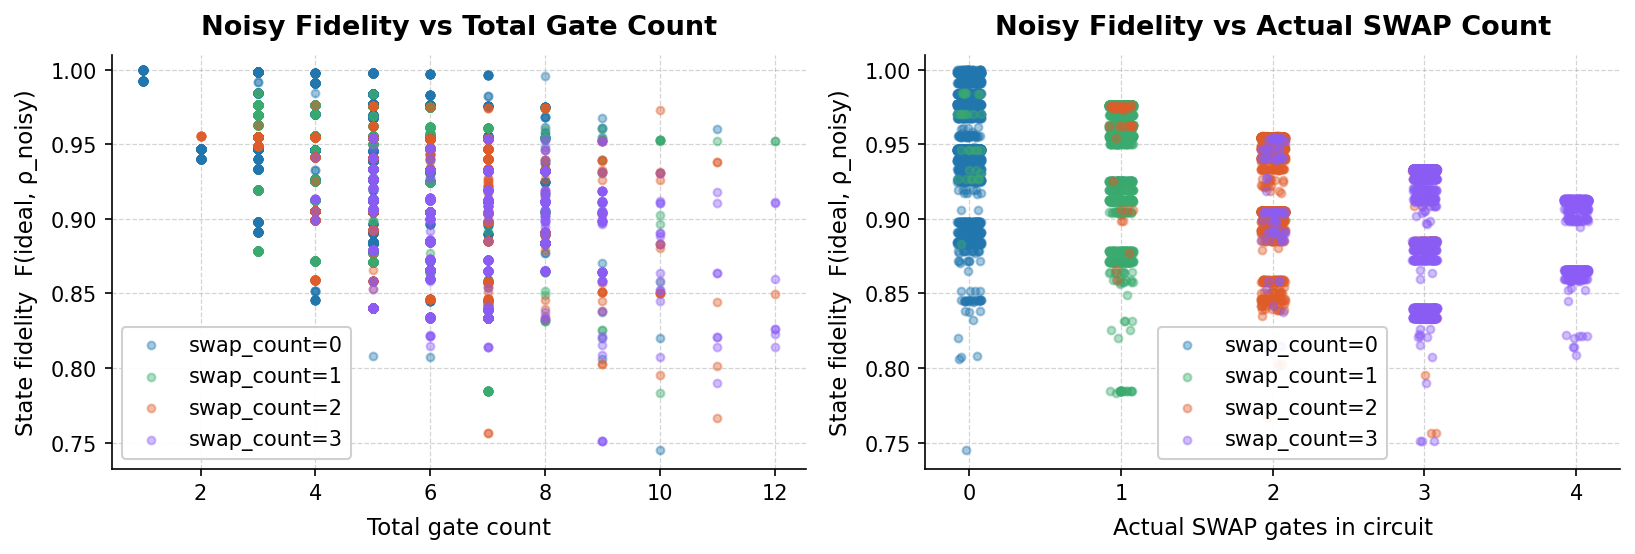

In [10]:
# ── Figure 3: Noisy fidelity vs. gate count scatter ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# Left: fidelity vs total gate count (all exact circuits, coloured by swap_count_req)
for sc in SWAP_COUNTS:
    sub = df_exact[df_exact["swap_count_req"] == sc]
    axes[0].scatter(
        sub["total_gates"], sub["noisy_fidelity"],
        alpha=0.4, s=14, color=SWAP_COLORS[sc], label=f"swap_count={sc}",
    )
axes[0].set_xlabel("Total gate count")
axes[0].set_ylabel("State fidelity  F(ideal, ρ_noisy)")
axes[0].set_title("Noisy Fidelity vs Total Gate Count")
axes[0].legend()
axes[0].set_ylim(None, 1.01)

# Right: fidelity vs actual SWAP gates
for sc in SWAP_COUNTS:
    sub = df_exact[df_exact["swap_count_req"] == sc]
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, len(sub))
    axes[1].scatter(
        sub["actual_swap"] + jitter, sub["noisy_fidelity"],
        alpha=0.4, s=14, color=SWAP_COLORS[sc], label=f"swap_count={sc}",
    )
axes[1].set_xlabel("Actual SWAP gates in circuit")
axes[1].set_ylabel("State fidelity  F(ideal, ρ_noisy)")
axes[1].set_title("Noisy Fidelity vs Actual SWAP Count")
axes[1].legend()
axes[1].set_ylim(None, 1.01)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "fidelity_vs_gate_count.png")
plt.show()


In [11]:
# ── Figure 4: Noise sweep — mean fidelity vs CX error rate ───────────────────
# Re-simulate a subset of circuits at several error rates to show how the
# fidelity gap evolves with noise level.

P2_SWEEP = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05]
SWEEP_N  = 32   # circuits per (swap_count, noise_level); balanced sample

# Build balanced sample: for each swap_count, take up to SWEEP_N exact circuits
# that are available from df_exact (already simulated once)
# We will re-run simulation at different noise levels for these circuits.

# Collect circuits we need
sweep_circuits = {sc: [] for sc in SWAP_COUNTS}
for idx in eval_indices:
    for sc in SWAP_COUNTS:
        if len(sweep_circuits[sc]) >= SWEEP_N:
            continue
        sub = df_exact[(df_exact["dataset_idx"] == idx) & (df_exact["swap_count_req"] == sc)]
        if len(sub) == 0:
            continue
        # Need to regenerate circuits; store idx + sc for re-generation
        sweep_circuits[sc].append(idx)

# Re-generate circuits for the sweep at sweep indices
print("Generating sweep circuits...")
sweep_rows = []   # {sc, idx, qc}
for sc in SWAP_COUNTS:
    prompt = make_prompt(sc)
    indices = list(dict.fromkeys(sweep_circuits[sc]))[:SWEEP_N]  # unique indices
    for idx in tqdm(indices, desc=f"sc={sc}", leave=False):
        target_u_split = eval_dataset.U[idx].cpu()
        target_u = get_reference_unitary(idx)
        tensors_out = generate_compilation_tensors(
            pipeline=finetuned_pipeline,
            prompt=[prompt],
            U=target_u_split.float().unsqueeze(0).to(device),
            samples=SAMPLES_PER_UNITARY,
            system_size=eval_dataset.x.shape[1],
            num_of_qubits=getattr(eval_dataset.params_config, "num_of_qubits", eval_dataset.x.shape[1]),
            max_gates=MAX_GATES,
            g=GUIDANCE_SCALE,
            auto_batch_size=AUTO_BATCH_SIZE,
            enable_params=False,
            no_bar=True,
        )
        decoded, _ = decode_tensors_to_backend(
            simulator=simulator, tokenizer=tokenizer,
            tensors=tensors_out, params=None, silent=True, n_jobs=1, filter_errs=False,
        )
        for qc in decoded:
            if qc is None:
                continue
            gen_u = simulator.backend.get_unitary(qc)
            infidelity = float(UnitaryInfidelityNorm.distance(
                torch.as_tensor(gen_u).to(torch.complex128),
                torch.as_tensor(target_u).to(torch.complex128),
            ).item())
            if infidelity <= EXACT_DISTANCE_TOL:
                sweep_rows.append({"sc": sc, "idx": idx, "qc": qc})
                break   # one exact circuit per (unitary, sc) is enough

print(f"Sweep circuits collected: {[(sc, sum(1 for r in sweep_rows if r['sc']==sc)) for sc in SWAP_COUNTS]}")


Generating sweep circuits...


sc=0:   0%|          | 0/32 [00:00<?, ?it/s]

sc=1:   0%|          | 0/32 [00:00<?, ?it/s]

sc=2:   0%|          | 0/32 [00:00<?, ?it/s]

sc=3:   0%|          | 0/32 [00:00<?, ?it/s]

Sweep circuits collected: [(0, 31), (1, 32), (2, 31), (3, 32)]


In [12]:
# Run noise sweep
print("Running noise sweep...")
sweep_data = []  # {sc, p2, fidelity}

for p2 in tqdm(P2_SWEEP, desc="Noise levels"):
    p1_scaled = p2 * 0.1
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1_scaled, 1), ["h","x","z","s","t","sdg","tdg"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2,      2), ["cx"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2 * 3,  2), ["swap"])
    nm.add_all_qubit_quantum_error(depolarizing_error(p2 * 6,  3), ["ccx"])
    sim_sweep = AerSimulator(noise_model=nm, method="density_matrix")

    for row in sweep_rows:
        sc = row["sc"]
        qc = row["qc"]
        try:
            ideal_sv = get_ideal_sv(qc)
            qc_sim = qc.copy()
            qc_sim.save_density_matrix()
            result = sim_sweep.run(qc_sim, shots=1).result()
            noisy_dm = result.data(0)["density_matrix"]
            fid = float(state_fidelity(DensityMatrix(ideal_sv), noisy_dm))
        except Exception:
            fid = float("nan")
        sweep_data.append({"swap_count_req": sc, "p2": p2, "fidelity": fid})

sweep_df = pd.DataFrame(sweep_data)
sweep_mean = sweep_df.groupby(["swap_count_req", "p2"])["fidelity"].agg(["mean","std"]).reset_index()
print("Sweep done.")


Running noise sweep...


Noise levels:   0%|          | 0/6 [00:00<?, ?it/s]

Sweep done.


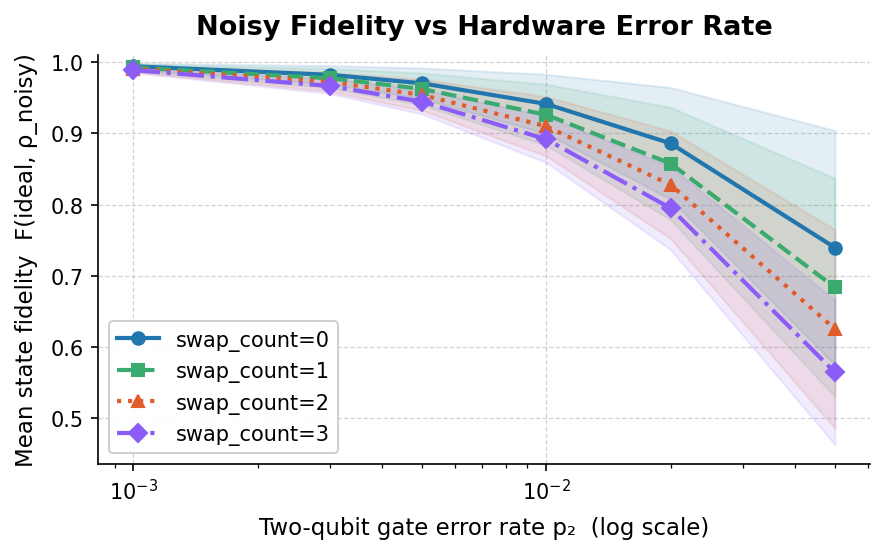

PosixPath('/home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-noise/noise_simulation/noise_sweep_summary.csv')

In [13]:
# ── Plot noise sweep ──────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 3.8))

ls_map = {0: "-", 1: "--", 2: ":", 3: "-."}
marker_map = {0: "o", 1: "s", 2: "^", 3: "D"}

for sc in SWAP_COUNTS:
    sub = sweep_mean[sweep_mean["swap_count_req"] == sc]
    ax.plot(
        sub["p2"], sub["mean"],
        color=SWAP_COLORS[sc], label=f"swap_count={sc}",
        linestyle=ls_map[sc], marker=marker_map[sc], markersize=6,
    )
    ax.fill_between(
        sub["p2"],
        sub["mean"] - sub["std"],
        sub["mean"] + sub["std"],
        color=SWAP_COLORS[sc], alpha=0.12,
    )

ax.set_xscale("log")
ax.set_xlabel("Two-qubit gate error rate p₂  (log scale)")
ax.set_ylabel("Mean state fidelity  F(ideal, ρ_noisy)")
ax.set_title("Noisy Fidelity vs Hardware Error Rate")
ax.legend(loc="lower left")
ax.set_ylim(None, 1.01)

fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "noise_sweep.png")
plt.show()

save_dataframe(sweep_mean, ARTIFACT_DIR / "noise_sweep_summary.csv", index=False)


In [14]:
# ── Save all raw results ──────────────────────────────────────────────────────

save_dataframe(df_all,   ARTIFACT_DIR / "all_circuits.csv",   index=False)
save_dataframe(df_exact, ARTIFACT_DIR / "exact_circuits.csv", index=False)

save_json({
    "eval_dataset_path":   EVAL_DATASET_PATH,
    "finetuned_model_dir": FINETUNED_MODEL_DIR,
    "swap_counts":         SWAP_COUNTS,
    "num_eval_unitaries":  NUM_EVAL_UNITARIES,
    "samples_per_unitary": SAMPLES_PER_UNITARY,
    "guidance_scale":      GUIDANCE_SCALE,
    "exact_distance_tol":  EXACT_DISTANCE_TOL,
    "noise_model":         {"p1": P1, "p2": P2, "p_swap": P_SWAP, "p_ccx": P_CCX},
    "p2_sweep":            P2_SWEEP,
    "seed":                SEED,
    "summary":             summary_rows,
}, ARTIFACT_DIR / "run_config.json")

print(f"All artifacts saved to {ARTIFACT_DIR}")


All artifacts saved to /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/unitary-swap-noise/noise_simulation


## Interpretation

**Figure 1 (box plot):** State fidelity under a realistic depolarising noise model
for exact circuits generated at each requested SWAP count.  Higher = better hardware performance.
The expected ordering is swap_count=0 > swap_count=1 > swap_count=2 > swap_count=3,
as each additional SWAP gate introduces ~3% extra depolarising error.

**Figure 2 (histograms):** Gate count and actual SWAP count distributions.
Confirms the model correctly produces circuits with the requested number of SWAPs.
Note that total gate count may be higher for swap_count=0 (alternative routing with more 1-qubit gates),
but the reduced SWAP count still yields better noise performance.

**Figure 3 (scatter):** Each point is one exact circuit.  The negative correlation
between gate count and fidelity, and between SWAP count and fidelity, is visible.
The clustering by swap_count_req colour shows the model's conditional distribution is well-separated.

**Figure 4 (noise sweep):** As hardware error rate increases, the fidelity gap between
swap_count=0 and higher counts widens.  At typical IBM rates (p₂ ≈ 1 %), the gap is already
measurable; at p₂ ≈ 5 % (near-term devices with heavy crosstalk), it becomes substantial.
This demonstrates that SWAP-count conditioning is practically relevant for real hardware.
